In [8]:
import json
import os
import random
import string
from pathlib import Path
import csv
from typing import List, Dict

In [9]:
DATA_DIR = ".././Data"
OUT_DIR = "./processedData"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

LAYMAN_MAP_PATH = "ddxplus/layman_dictionary.json"   # optional
USE_LLM_FOR_LAYMAN = False  # set to True if you will fill the LLM function

In [3]:
def load_evidence_map(path: str) -> Dict:
    return json.load(open(path))


def map_evidences(evidence_ids: List[str], evidence_map: Dict):
    symptoms, risk_factors, labs = [], [], []

    for evid in evidence_ids:
        if evid not in evidence_map:
            # corrupted or missing ID
            continue
        e = evidence_map[evid]
        name = e.get("name", "").strip().lower()
        typ = e.get("type", "")

        if "symptom" in typ:
            symptoms.append(name)
        elif "risk" in typ:
            risk_factors.append(name)
        elif "lab" in typ:
            labs.append(name)

    return symptoms, risk_factors, labs

In [4]:
def parse_ddxplus_csv(csv_path: str, evidence_map: Dict):
    records = []

    with open(csv_path, newline='', encoding='utf8') as f:
        reader = csv.DictReader(f)

        for row in reader:
            evid_raw = row["EVIDENCES"].strip()
            evid_list = json.loads(evid_raw.replace("'", '"'))

            symptoms, risks, labs = map_evidences(evid_list, evidence_map)

            # parse differential diagnosis list
            ddx_list = json.loads(row["DIFFERENTIAL_DIAGNOSIS"].replace("'", '"'))

            ddx_list = [
                {"condition": cond, "score": float(score)}
                for cond, score in ddx_list
            ]

            rec = {
                "id": len(records),
                "age": int(row["AGE"]),
                "sex": row["SEX"],
                "final_diagnosis": row["PATHOLOGY"],
                "symptoms": symptoms,
                "risk_factors": risks,
                "labs": labs,
                "raw_evidence_ids": evid_list,
                "differential": ddx_list
            }
            records.append(rec)

    return records


In [5]:
def inject_typo(word: str) -> str:
    if len(word) < 4:
        return word

    ops = ["insert", "delete", "swap", "replace"]
    op = random.choice(ops)
    i = random.randint(0, len(word)-1)

    if op == "insert":
        return word[:i] + random.choice(string.ascii_lowercase) + word[i:]
    elif op == "delete":
        return word[:i] + word[i+1:]
    elif op == "swap" and i < len(word)-1:
        return word[:i] + word[i+1] + word[i] + word[i+2:]
    elif op == "replace":
        return word[:i] + random.choice(string.ascii_lowercase) + word[i+1:]
    return word


def make_typo_variant(records):
    out = []
    for r in records:
        new_r = r.copy()
        noisy = []
        for s in r["symptoms"]:
            if random.random() < 0.3:  # 30% chance to corrupt
                noisy.append(inject_typo(s))
            else:
                noisy.append(s)
        new_r["symptoms"] = noisy
        out.append(new_r)
    return out

In [6]:
def make_missinginfo_variant(records):
    out = []
    for r in records:
        new_r = r.copy()
        symptoms = r["symptoms"]
        if len(symptoms) == 0:
            new_r["symptoms"] = symptoms
        else:
            keep_n = max(1, int(len(symptoms) * 0.6))
            new_r["symptoms"] = random.sample(symptoms, keep_n)
        out.append(new_r)
    return out

In [7]:
NOISE_POOL = [
    "itchy scalp", "hiccups", "toe pain", "mild ankle stiffness", "eye twitch",
    "runny nose", "sneezing", "dandruff", "mild headache", "dry lips",
    "stomach rumbling", "transient dizziness"
]

def make_overcomplete_variant(records):
    out = []
    for r in records:
        new_r = r.copy()
        extra = random.sample(NOISE_POOL, random.randint(2, 4))
        new_r["symptoms"] = r["symptoms"] + extra
        out.append(new_r)
    return out

In [8]:
def llm_convert_to_layman(text: str) -> str:
    """
    You MUST fill this if USE_LLM_FOR_LAYMAN = True.
    Pseudocode:

    response = openai.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "user",
            "content": f"Rewrite the medical symptom '{text}' into a simple patient-friendly description, 3-8 words, no medical jargon."
        }]
    )
    return response.choices[0].message["content"]
    """
    raise NotImplementedError("LLM API not connected.")


def make_layman_variant(records, layman_dict=None):
    out = []
    for r in records:
        new_r = r.copy()
        new_symptoms = []
        for s in r["symptoms"]:
            if layman_dict and s in layman_dict:
                new_symptoms.append(layman_dict[s])
            else:
                if USE_LLM_FOR_LAYMAN:
                    new_symptoms.append(llm_convert_to_layman(s))
                else:
                    # fallback: simple transformation
                    new_symptoms.append(f"feeling of {s}")
        new_r["symptoms"] = new_symptoms
        out.append(new_r)
    return out

In [9]:
def write_jsonl(path: str, records: List[Dict]):
    with open(path, "w", encoding="utf8") as f:
        for r in records:
            f.write(json.dumps(r) + "\n")

In [10]:
print("Loading evidence map...")
evidence_map = load_evidence_map(os.path.join(DATA_DIR, "release_evidences.json"))

Loading evidence map...


In [11]:
print("Parsing raw DDxPlus CSV...")
csv_path = os.path.join(DATA_DIR, "release_train_patients")  
records = parse_ddxplus_csv(csv_path, evidence_map)

Parsing raw DDxPlus CSV...


In [12]:
print("Writing original dataset...")
write_jsonl(os.path.join(OUT_DIR, "ddxplus_original.jsonl"), records)

Writing original dataset...


In [13]:
print("Generating typo variant...")
typo_variants = make_typo_variant(records)
write_jsonl(os.path.join(OUT_DIR, "ddxplus_typo.jsonl"), typo_variants)

Generating typo variant...


In [14]:
print("Generating missing-info variant...")
missinginfo_variants = make_missinginfo_variant(records)
write_jsonl(os.path.join(OUT_DIR, "ddxplus_missinginfo.jsonl"), missinginfo_variants)

Generating missing-info variant...


In [15]:
print("Generating overcomplete-noise variant...")
overcomplete_variants = make_overcomplete_variant(records)
write_jsonl(os.path.join(OUT_DIR, "ddxplus_overcomplete.jsonl"), overcomplete_variants)

Generating overcomplete-noise variant...


In [16]:
print("Generating layman-language variant...")
layman_dict = None
if os.path.exists(LAYMAN_MAP_PATH):
    layman_dict = json.load(open(LAYMAN_MAP_PATH))
layman_variants = make_layman_variant(records, layman_dict)
write_jsonl(os.path.join(OUT_DIR, "ddxplus_layman.jsonl"), layman_variants)

Generating layman-language variant...


In [5]:
%pip install pandas

  Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   --------------------- ------------------ 6.0/11.0 MB 30.7 MB/s eta 0:00:01
   ------------------------------------- -- 10.2/11.0 MB 24.5 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 22.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   -------------- ------------------------- 4.7/12.8 MB 21.8 MB/s eta 0:00:01
   --------------------------- ------------ 8.9/12.8 MB 21.3 MB/s eta 0:00:01
   ---------------------------------------  12.6/12.8 MB 20.2 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 19.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import ast

df = pd.read_csv(".././Data/Open-XDDx.csv")

# parse interpretation dict column
df["interpretation_dict"] = df["interpretation"].apply(ast.literal_eval)

# number of diagnoses per case
df["num_diagnoses"] = df["interpretation_dict"].apply(lambda d: len(d))

# flatten diagnoses
df["diagnosis_names"] = df["interpretation_dict"].apply(lambda d: list(d.keys()))


In [2]:
print("Number of cases:", len(df))

Number of cases: 570


In [6]:
df.head(1)
print("Interpretation dict example: ", df["interpretation_dict"].iloc[0])
df["interpretation_dict"].iloc[0]

Interpretation dict example:  {'acute kidney injury (AKI)': ['decreased urinary output', 'malaise', 'Serum Urea nitrogen 25 mg/dL', 'Creatinine 4.2 mg/dL'], 'contrast-induced nephropathy': ['Two weeks after undergoing an emergency cardiac catherization with stenting for unstable angina pectoris, a 61-year-old man has decreased urinary output and malaise', 'Serum Urea nitrogen 25 mg/dL', 'Creatinine 4.2 mg/dL'], 'drug-induced interstitial nephritis': ['decreased urinary output and malaise', 'eosinophils 11%', 'Serum Urea nitrogen 25 mg/dL', 'Creatinine 4.2 mg/dL', 'Renal biopsy shows intravascular spindle-shaped vacuoles'], 'cholesterol embolization': ['mottled, reticulated purplish discoloration of the feet', 'Serum Urea nitrogen 25 mg/dL', 'Creatinine 4.2 mg/dL', 'intravascular spindle-shaped vacuoles'], 'diabetic nephropathy': ['decreased urinary output', 'Serum Urea nitrogen 25 mg/dL', 'Creatinine 4.2 mg/dL']}


{'acute kidney injury (AKI)': ['decreased urinary output',
  'malaise',
  'Serum Urea nitrogen 25 mg/dL',
  'Creatinine 4.2 mg/dL'],
 'contrast-induced nephropathy': ['Two weeks after undergoing an emergency cardiac catherization with stenting for unstable angina pectoris, a 61-year-old man has decreased urinary output and malaise',
  'Serum Urea nitrogen 25 mg/dL',
  'Creatinine 4.2 mg/dL'],
 'drug-induced interstitial nephritis': ['decreased urinary output and malaise',
  'eosinophils 11%',
  'Serum Urea nitrogen 25 mg/dL',
  'Creatinine 4.2 mg/dL',
  'Renal biopsy shows intravascular spindle-shaped vacuoles'],
 'cholesterol embolization': ['mottled, reticulated purplish discoloration of the feet',
  'Serum Urea nitrogen 25 mg/dL',
  'Creatinine 4.2 mg/dL',
  'intravascular spindle-shaped vacuoles'],
 'diabetic nephropathy': ['decreased urinary output',
  'Serum Urea nitrogen 25 mg/dL',
  'Creatinine 4.2 mg/dL']}

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 570 entries, 0 to 569
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Index                570 non-null    int64 
 1   patient_info         570 non-null    object
 2   disease_num          570 non-null    int64 
 3   rationale_num        570 non-null    int64 
 4   interpretation       570 non-null    object
 5   specialty            570 non-null    object
 6   interpretation_dict  570 non-null    object
 7   num_diagnoses        570 non-null    int64 
 8   diagnosis_names      570 non-null    object
dtypes: int64(4), object(5)
memory usage: 40.2+ KB


In [5]:
df.isna().sum()

Index                  0
patient_info           0
disease_num            0
rationale_num          0
interpretation         0
specialty              0
interpretation_dict    0
num_diagnoses          0
diagnosis_names        0
dtype: int64

In [6]:
df.describe().all()

Index            True
disease_num      True
rationale_num    True
num_diagnoses    True
dtype: bool

In [7]:
df["dict_size"] = df["interpretation_dict"].apply(len)
df[df["dict_size"] != df["disease_num"]]

,Index,patient_info,disease_num,rationale_num,interpretation,specialty,interpretation_dict,num_diagnoses,diagnosis_names,dict_size


In [8]:
df.head()

,Index,patient_info,disease_num,rationale_num,interpretation,specialty,interpretation_dict,num_diagnoses,diagnosis_names,dict_size
0,1,Two weeks after undergoing an emergency cardia...,5,19,{'acute kidney injury (AKI)': ['decreased urin...,Endocrine disorder,{'acute kidney injury (AKI)': ['decreased urin...,5,"[acute kidney injury (AKI), contrast-induced n...",5
1,2,A 30-year-old African American woman comes to ...,4,13,{'community-acquired pneumonia': ['dry cough a...,Respiratory disease,{'community-acquired pneumonia': ['dry cough a...,4,"[community-acquired pneumonia, allergic bronch...",4
2,3,A 67-year-old man who was diagnosed with arthr...,6,26,{'osteoarthritis': ['right knee swelling and p...,Orthopedic disease,{'osteoarthritis': ['right knee swelling and p...,6,"[osteoarthritis, rheumatoid arthritis, gout, p...",6
3,4,A one-day-old male is evaluated in the hospita...,6,16,{'Hirschsprung disease': ['the patient has uri...,Digestive system disease,{'Hirschsprung disease': ['the patient has uri...,6,"[Hirschsprung disease, meconium ileus, intesti...",6
4,5,A 55-year-old man comes to the physician becau...,3,8,{'peripheral artery disease (PAD)': ['a 6-week...,Circulatory system disease,{'peripheral artery disease (PAD)': ['a 6-week...,3,"[peripheral artery disease (PAD), lumbar spina...",3


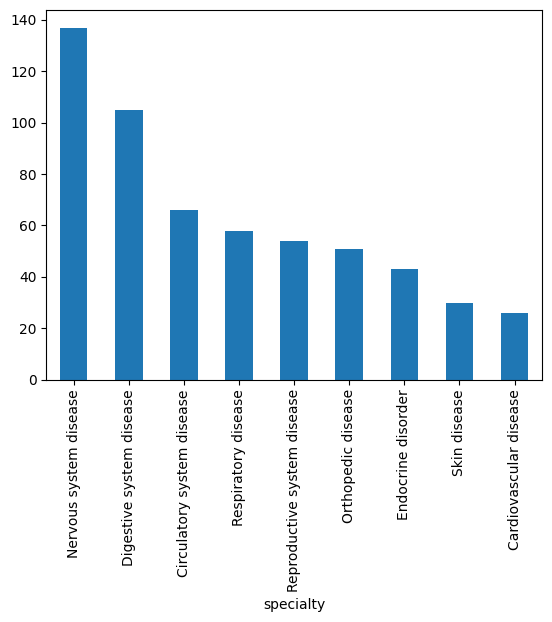

specialty
Nervous system disease         137
Digestive system disease       105
Circulatory system disease      66
Respiratory disease             58
Reproductive system disease     54
Orthopedic disease              51
Endocrine disorder              43
Skin disease                    30
Cardiovascular disease          26
Name: count, dtype: int64


In [9]:
import matplotlib.pyplot as plt
df["specialty"].value_counts().plot(kind="bar")
plt.show()
print(df["specialty"].value_counts())

In [10]:
df["patient_len"] = df["patient_info"].apply(lambda x: len(x.split()))
df["rationale_len"] = df["interpretation"].apply(lambda x: len(x.split()))

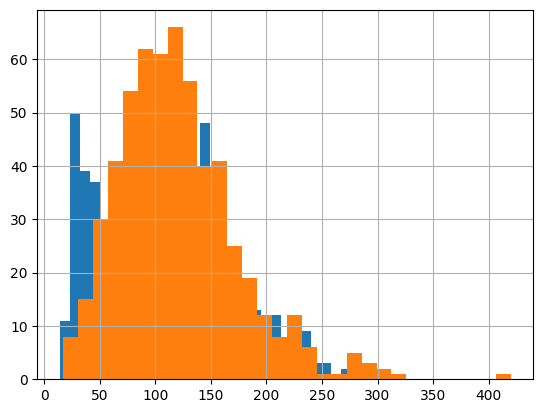

Patient info length stats:
count    570.000000
mean     113.726316
std       60.322090
min       14.000000
25%       54.000000
50%      120.000000
75%      152.000000
max      285.000000
Name: patient_len, dtype: float64
Rationale length stats:
count    570.000000
mean     120.122807
std       54.257788
min       17.000000
25%       83.000000
50%      114.000000
75%      148.000000
max      420.000000
Name: rationale_len, dtype: float64


In [11]:
df["patient_len"].hist(bins=30)
df["rationale_len"].hist(bins=30)
plt.show()
print("Patient info length stats:")
print(df["patient_len"].describe())
print("Rationale length stats:")
print(df["rationale_len"].describe())

In [12]:
rows = []
for idx, row in df.iterrows():
    for dx, symptoms in row["interpretation_dict"].items():
        rows.append({"index": row["Index"], "diagnosis": dx, "num_symptoms": len(symptoms)})
flat = pd.DataFrame(rows)

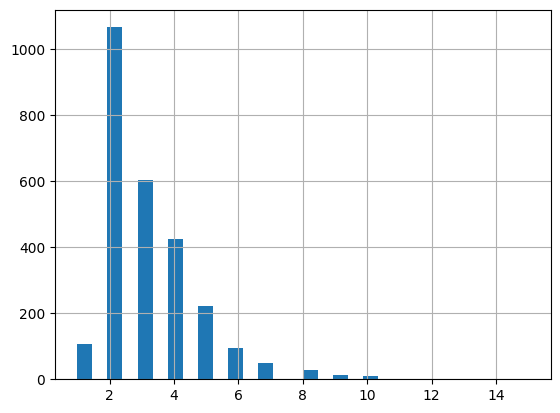

Number of symptoms stats:
count    2619.000000
mean        3.148148
std         1.559921
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        15.000000
Name: num_symptoms, dtype: float64


In [13]:
flat.head()
flat["num_symptoms"].hist(bins=30)
plt.show()
flat.__len__()
print("Number of symptoms stats:")
print(flat["num_symptoms"].describe())  

In [14]:
flat["diagnosis"].value_counts().head(20)
flat["diagnosis"].value_counts().tail(20)

diagnosis
bladder or kidney injury                        1
renal cell carcinoma                            1
side effects of chemotherapy                    1
Cyclophosphamide                                1
Horner syndrome                                 1
Botulism                                        1
Posttraumatic stress disorder                   1
Psychotic or delusional disorder                1
Obstructive sleep apnea                         1
Chronic fatigue syndrome                        1
Narcolepsy                                      1
COPD exacerbation (bronchitis)                  1
Pneumonia (including Pneumocystis jirovecii)    1
Asthma                                          1
Sickle cell disease                             1
Pericarditis                                    1
Smoking cessation                               1
Drug side effect                                1
Insulinoma                                      1
Reactive postprandial hypoglycemia      

In [15]:
from collections import Counter

symptoms = Counter()
for d in df["interpretation_dict"]:
    for k, v in d.items():
        for s in v:
            symptoms[s] += 1

symptoms_df = pd.DataFrame(symptoms.items(), columns=["symptom", "count"]).sort_values("count", ascending=False)

In [16]:
symptoms_df.head(20)

,symptom,count
197,fever,35
3060,vomiting,23
453,nausea,22
633,fatigue,19
786,weight loss,19
616,nausea and vomiting,14
3009,dyspnea,13
659,Crackles are heard at both lung bases,12
3903,dizziness that started this morning,10
280,shortness of breath,9


In [17]:
import itertools
from collections import Counter

pair_counter = Counter()

for diags in df["diagnosis_names"]:
    for a, b in itertools.combinations(sorted(diags), 2):
        pair_counter[(a, b)] += 1

pair_df = pd.DataFrame(
    [{"dx1": a, "dx2": b, "count": c} for (a,b),c in pair_counter.items()]
).sort_values("count", ascending=False)


In [18]:
pair_df.head(20)

,dx1,dx2,count
24,gout,rheumatoid arthritis,6
27,osteoarthritis,rheumatoid arthritis,6
21,gout,osteoarthritis,5
30,psoriatic arthritis,rheumatoid arthritis,5
3295,Chronic bronchitis,Pneumonia,5
3297,Chronic bronchitis,Tracheaectasy,5
3302,Pneumonia,Tracheaectasy,5
203,Alzheimer's disease,Lewy body dementia,4
26,osteoarthritis,psoriatic arthritis,4
588,lung cancer,tuberculosis,4


In [19]:
df["difficulty"] = df["num_diagnoses"] * df["patient_len"]
df.sort_values("difficulty", ascending=False).head(10)

,Index,patient_info,disease_num,rationale_num,interpretation,specialty,interpretation_dict,num_diagnoses,diagnosis_names,dict_size,patient_len,rationale_len,difficulty
290,291,A 62-year-old woman is seen in the hospital fo...,7,26,{'hemolytic transfusion reactions': ['she beca...,Circulatory system disease,{'hemolytic transfusion reactions': ['she beca...,7,"[hemolytic transfusion reactions, transfusion-...",7,218,161,1526
79,80,"A 29-year-old woman, gravida 3, para 2, at 24 ...",7,15,"{'placental abruption': ['vaginal bleeding', '...",Reproductive system disease,"{'placental abruption': ['vaginal bleeding', '...",7,"[placental abruption, placenta previa, vasa pr...",7,211,138,1477
164,165,A 65-year-old man presents to the emergency de...,6,23,{'cerebrovascular accident (CVA or stroke)': [...,Nervous system disease,{'cerebrovascular accident (CVA or stroke)': [...,6,"[cerebrovascular accident (CVA or stroke), tra...",6,240,207,1440
283,284,A 70-year-old man comes to the physician for t...,6,16,{'diverticular disease': ['the patient has had...,Digestive system disease,{'diverticular disease': ['the patient has had...,6,"[diverticular disease, gastrointestinal malign...",6,223,153,1338
117,118,An 8-year-old boy is brought to the physician ...,6,19,"{'hypothyroidism': ['short stature', 'Thyroid-...",Endocrine disorder,"{'hypothyroidism': ['short stature', 'Thyroid-...",6,"[hypothyroidism, growth hormone deficiency, co...",6,214,172,1284
337,338,A 32-year-old woman presents to a psychiatrist...,5,10,{'Major Depressive Disorder with Psychotic fea...,Nervous system disease,{'Major Depressive Disorder with Psychotic fea...,5,[Major Depressive Disorder with Psychotic feat...,5,256,119,1280
311,312,A 67-year-old woman comes to the emergency dep...,7,16,{'orthostatic hypotension': ['blood pressure i...,Circulatory system disease,{'orthostatic hypotension': ['blood pressure i...,7,"[orthostatic hypotension, vasovagal syncope, c...",7,181,284,1267
268,269,A 30-year-old forest landscape specialist is b...,6,49,{'sepsis': ['she is restless and her temperatu...,Circulatory system disease,{'sepsis': ['she is restless and her temperatu...,6,"[sepsis, dengue, malaria, Marburg virus, Ebola...",6,211,303,1266
263,264,A 62-year-old woman is brought to the emergenc...,5,11,{'central retinal artery occlusion (CRAO)': ['...,Nervous system disease,{'central retinal artery occlusion (CRAO)': ['...,5,"[central retinal artery occlusion (CRAO), cent...",5,249,177,1245
347,348,A 73-year-old woman is brought to the physicia...,6,30,"{'normal aging': [""Initially, she used to misp...",Nervous system disease,"{'normal aging': ['Initially, she used to misp...",6,"[normal aging, mild cognitive impairment, Alzh...",6,205,324,1230


In [20]:
def has_leakage(row):
    text = row["patient_info"].lower()
    for dx in row["diagnosis_names"]:
        if dx.lower() in text:
            return True
    return False

df["leakage"] = df.apply(has_leakage, axis=1)
df["leakage"].sum()

np.int64(31)

In [23]:
df[df["leakage"] == True]

,Index,patient_info,disease_num,rationale_num,interpretation,specialty,interpretation_dict,num_diagnoses,diagnosis_names,dict_size,patient_len,rationale_len,difficulty,leakage
26,27,A 13-year-old boy is brought to his pediatrici...,6,15,{'gynecomastia': ['a left breast lump under hi...,Reproductive system disease,{'gynecomastia': ['a left breast lump under hi...,6,"[gynecomastia, breast cancer, fibroadenoma, li...",6,168,154,1008,True
38,39,A 47-year-old woman comes to the physician for...,5,13,"{""Parkinson's disease"": ['A low-frequency trem...",Nervous system disease,{'Parkinson's disease': ['A low-frequency trem...,5,"[Parkinson's disease, Essential tremor, Multip...",5,149,126,745,True
57,58,A 38-year-old man is brought to the emergency ...,6,23,{'hypothermia': ['His rectal temperature is 32...,Endocrine disorder,{'hypothermia': ['His rectal temperature is 32...,6,"[hypothermia, hypothyroidism, side effects of ...",6,167,173,1002,True
66,67,A 33-year-old man presents to the emergency de...,6,11,{'recurrent pneumothorax': ['subcutaneous emph...,Respiratory disease,{'recurrent pneumothorax': ['subcutaneous emph...,6,"[recurrent pneumothorax, hemothorax, chest tub...",6,118,123,708,True
119,120,A 79-year-old woman comes to the physician for...,4,14,{'congestive heart failure': ['a 2-month histo...,Respiratory disease,{'congestive heart failure': ['a 2-month histo...,4,"[congestive heart failure, lung cancer, tuberc...",4,233,146,932,True
120,121,"A 66-year-old man with high blood pressure, hi...",4,9,{'non-alcoholic fatty liver disease (NAFLD)': ...,Digestive system disease,{'non-alcoholic fatty liver disease (NAFLD)': ...,4,"[non-alcoholic fatty liver disease (NAFLD), vi...",4,71,51,284,True
127,128,A 5-year-old girl is brought to the clinic by ...,4,14,{'precocious puberty': ['excessive hair growth...,Endocrine disorder,{'precocious puberty': ['excessive hair growth...,4,"[precocious puberty, adrenal tumor, ovarian tu...",4,98,86,392,True
152,153,A 17-year-old boy is brought to the physician ...,4,12,{'rheumatoid arthritis': ['His mother has rheu...,Orthopedic disease,{'rheumatoid arthritis': ['His mother has rheu...,4,"[rheumatoid arthritis, gout, septic arthritis,...",4,199,140,796,True
172,173,"Six hours after delivery, a 3050-g (6-lb 12-oz...",6,17,{'congenital malformation syndromes': ['epican...,Digestive system disease,{'congenital malformation syndromes': ['epican...,6,"[congenital malformation syndromes, Down syndr...",6,137,124,822,True
178,179,A 47-year-old woman comes to the physician bec...,4,22,"{'hepatitis A': ['generalized fatigue, mild fe...",Digestive system disease,"{'hepatitis A': ['generalized fatigue, mild fe...",4,"[hepatitis A, hepatitis B, alcoholic hepatitis...",4,212,118,848,True


In [22]:
df.groupby("specialty")["num_diagnoses"].mean()
df.groupby("specialty")["diagnosis_names"].apply(lambda x: len(set(sum(x, []))))

specialty
Cardiovascular disease          81
Circulatory system disease     246
Digestive system disease       346
Endocrine disorder             171
Nervous system disease         428
Orthopedic disease             151
Reproductive system disease    183
Respiratory disease            144
Skin disease                   100
Name: diagnosis_names, dtype: int64

In [10]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from collections import Counter
import re

# Pretty plots
plt.style.use('seaborn-v0_8')

In [13]:
TRAIN_PATH = ".././Data/release_train_patients."
VAL_PATH = ".././Data/release_validate_patients"
# TEST_PATH = ".././Data/release_test_patients"

COND_PATH = ".././Data/release_conditions.json"
EVID_PATH = ".././Data/release_evidences.json"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
# test_df = pd.read_csv(TEST_PATH)

with open(COND_PATH) as f:
    cond_meta = json.load(f)

with open(EVID_PATH) as f:
    evid_meta = json.load(f)

In [15]:
def parse_list(x):
    return ast.literal_eval(x) if isinstance(x, str) else x

train_df["DIFFERENTIAL_DIAGNOSIS"] = train_df["DIFFERENTIAL_DIAGNOSIS"].apply(parse_list)
train_df["EVIDENCES"] = train_df["EVIDENCES"].apply(parse_list)


In [16]:
def split_ev(entry):
    m = re.match(r"(E_\d+)(?:_@_(V_\d+))?", entry)
    return m.group(1), m.group(2) if m and m.group(2) else None

df["EV_PARSED"] = df["EVIDENCES"].apply(lambda lst: [split_ev(e) for e in lst])

In [25]:
type_counts = {"Binary":0, "Categorical":0, "Multi-choice":0}

for ev, meta in evid_meta.items():
    dt = meta.get("data_type")
    if dt == "B": type_counts["Binary"] += 1
    elif dt == "C": type_counts["Categorical"] += 1
    elif dt == "M": type_counts["Multi-choice"] += 1

evidence_df = pd.DataFrame.from_dict(type_counts, orient="index", columns=["Count"])
evidence_df["Percent"] = (evidence_df["Count"] / evidence_df["Count"].sum() * 100).round(2)
evidence_df


,Count,Percent
Binary,208,93.27
Categorical,10,4.48
Multi-choice,5,2.24


In [18]:
df["SYMPTOMS"] = df["EV_PARSED"].apply(lambda x: sum(meta.get(code, {}).get("is_antecedent")==False 
                                                     for code,_ in x))
df["ANTECEDENTS"] = df["EV_PARSED"].apply(lambda x: sum(meta.get(code, {}).get("is_antecedent")==True 
                                                       for code,_ in x))
df["TOTAL_EVID"] = df["SYMPTOMS"] + df["ANTECEDENTS"]

print(df[["TOTAL_EVID","SYMPTOMS","ANTECEDENTS"]].describe())


       TOTAL_EVID   SYMPTOMS  ANTECEDENTS
count   1025602.0  1025602.0    1025602.0
mean          0.0        0.0          0.0
std           0.0        0.0          0.0
min           0.0        0.0          0.0
25%           0.0        0.0          0.0
50%           0.0        0.0          0.0
75%           0.0        0.0          0.0
max           0.0        0.0          0.0


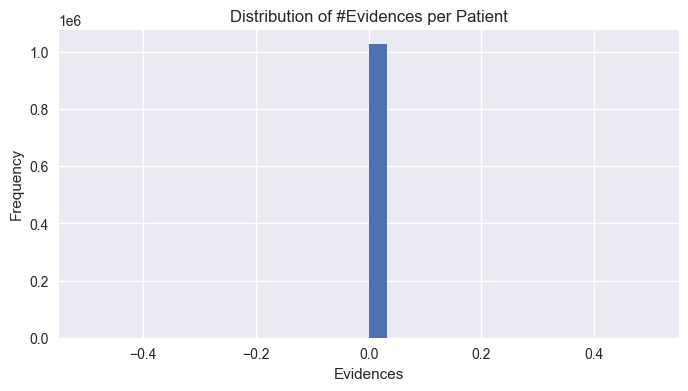

In [19]:
df["TOTAL_EVID"].plot(kind="hist", bins=30, figsize=(8,4))
plt.title("Distribution of #Evidences per Patient")
plt.xlabel("Evidences")
plt.show()


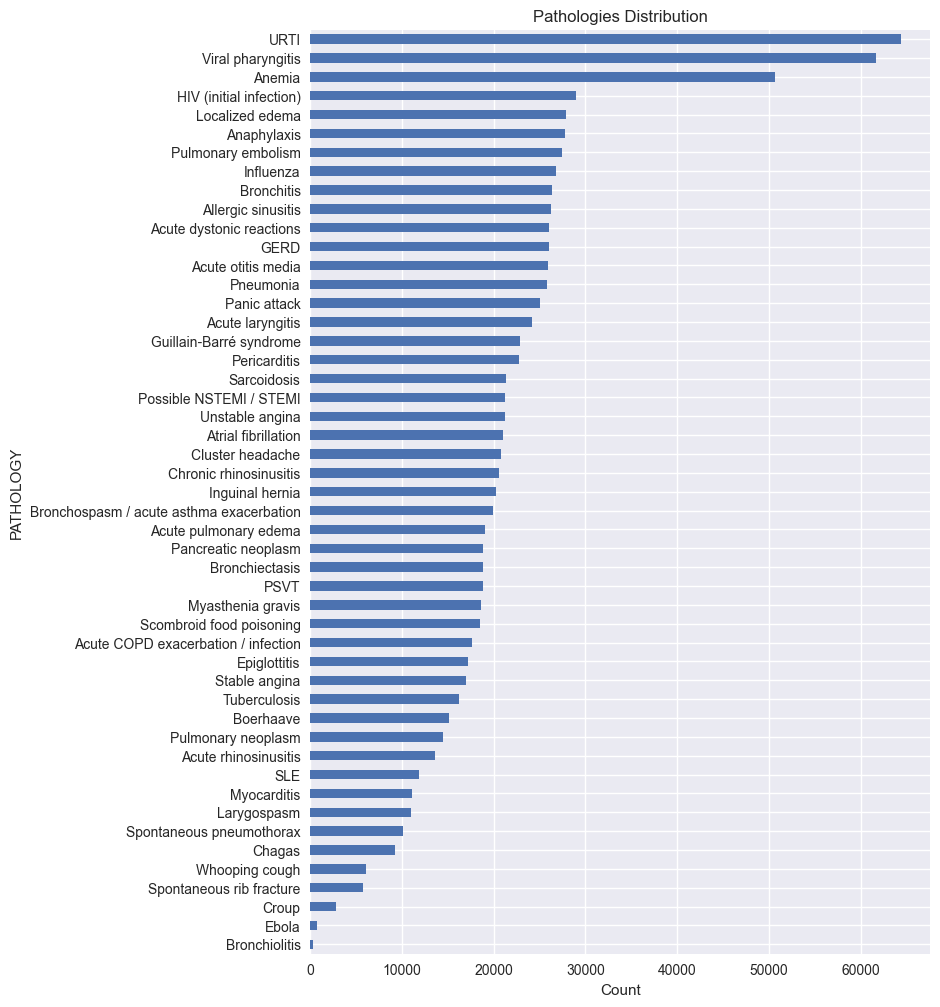

In [20]:
df["PATHOLOGY"].value_counts().sort_values(ascending=True).plot(
    kind="barh", figsize=(8,12))
plt.title("Pathologies Distribution")
plt.xlabel("Count")
plt.show()


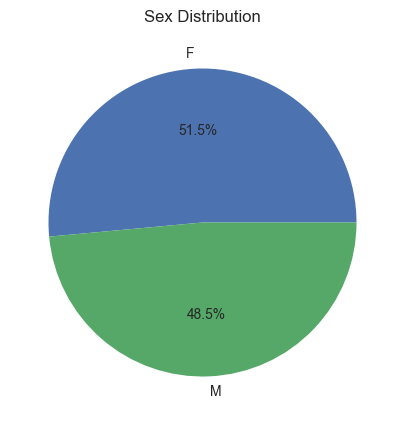

In [21]:
df["SEX"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(5,5))
plt.title("Sex Distribution")
plt.ylabel("")
plt.show()


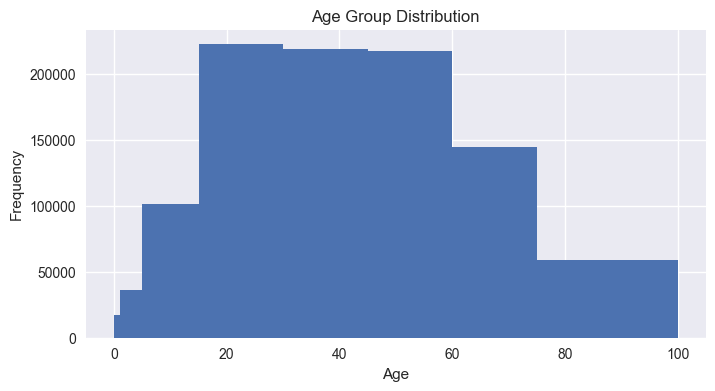

In [22]:
df["AGE"].plot(kind="hist", bins=[0,1,5,15,30,45,60,75,100], figsize=(8,4))
plt.title("Age Group Distribution")
plt.xlabel("Age")
plt.show()


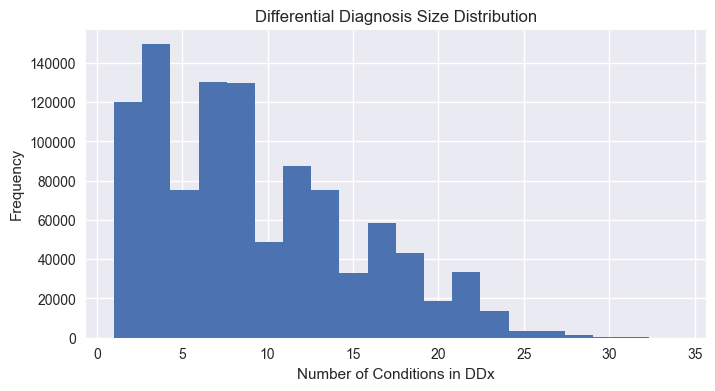

In [23]:
df["DDX_LEN"] = df["DIFFERENTIAL_DIAGNOSIS"].apply(len)

df["DDX_LEN"].plot(kind="hist", bins=20, figsize=(8,4))
plt.title("Differential Diagnosis Size Distribution")
plt.xlabel("Number of Conditions in DDx")
plt.show()


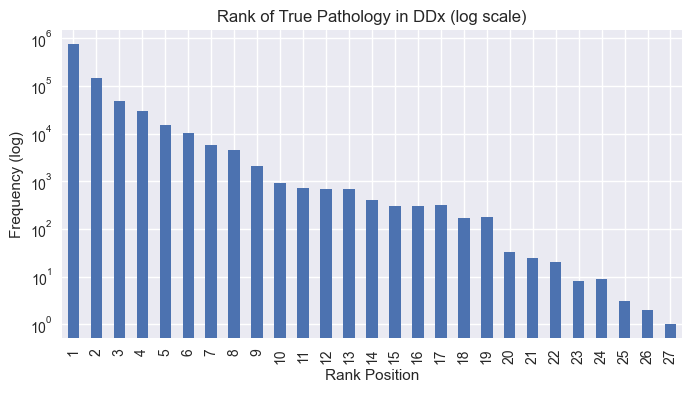

Top-1 Match Rate: 0.7367663089580558


In [24]:
def truth_rank(row):
    for i,(dis,_) in enumerate(row["DIFFERENTIAL_DIAGNOSIS"]):
        if dis == row["PATHOLOGY"]:
            return i+1
    return None

df["TRUTH_RANK"] = df.apply(truth_rank, axis=1)

df["TRUTH_RANK"].value_counts().sort_index().plot(kind="bar", logy=True, figsize=(8,4))
plt.title("Rank of True Pathology in DDx (log scale)")
plt.xlabel("Rank Position")
plt.ylabel("Frequency (log)")
plt.show()

print("Top-1 Match Rate:", (df["TRUTH_RANK"]==1).mean())


In [28]:
import json
import networkx as nx

# Load JSON metadata
conditions = json.load(open(".././Data/release_conditions.json"))
evidences = json.load(open(".././Data/release_evidences.json"))

KG = nx.DiGraph()

# Add diseases and their evidence relations
for cond_name, meta in conditions.items():
    KG.add_node(cond_name, type="disease")

    # Symptoms edges
    for evid in meta["symptoms"].keys():
        KG.add_node(evid, type="evidence")
        KG.add_edge(evid, cond_name, relation="has_symptom")

    # Antecedents edges
    for evid in meta["antecedents"].keys():
        KG.add_node(evid, type="evidence")
        KG.add_edge(evid, cond_name, relation="risk_factor")


In [31]:
import pandas as pd, ast
df = pd.read_csv(".././Data/release_train_patients")
df["DIFF"] = df["DIFFERENTIAL_DIAGNOSIS"].apply(ast.literal_eval)

# Co-occurrence edges (optional but good for multi-hop DDx)
for dlist in df["DIFF"]:
    diseases = [d for d,_ in dlist]
    for i in range(len(diseases)):
        for j in range(i+1, len(diseases)):
            KG.add_edge(diseases[i], diseases[j], relation="cooccur")
            KG.add_edge(diseases[j], diseases[i], relation="cooccur")


In [32]:
print("Total nodes:", KG.number_of_nodes())
print("Total edges:", KG.number_of_edges())

# Check node type distribution
from collections import Counter
print(Counter(nx.get_node_attributes(KG, "type").values()))

Total nodes: 272
Total edges: 3114
Counter({'evidence': 223, 'disease': 49})


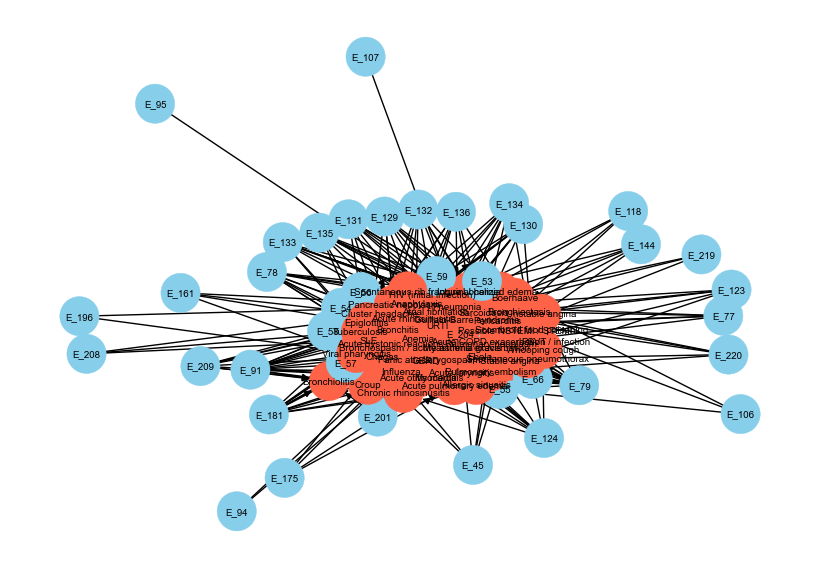

In [34]:
import matplotlib.pyplot as plt

def show_subgraph(center, hops=2):
    nodes = set([center])
    frontier = set([center])

    for _ in range(hops):
        new_f = set()
        for node in frontier:
            new_f.update(KG.predecessors(node))
            new_f.update(KG.successors(node))
        nodes.update(new_f)
        frontier = new_f

    sub = KG.subgraph(nodes)
    pos = nx.spring_layout(sub, seed=42)

    node_colors = ["tomato" if KG.nodes[n]["type"] == "disease" else "skyblue" for n in sub.nodes()]
    nx.draw(sub, pos, with_labels=True, node_color=node_colors, font_size=7, node_size=800)
    plt.show()

show_subgraph("Pneumonia", hops=1)


In [42]:
def extract_subgraph_for_symptoms(KG, symptoms, hops=1):
    nodes = set(symptoms)
    frontier = set(symptoms)

    for _ in range(hops):
        next_nodes = set()
        for node in frontier:
            next_nodes.update(KG.successors(node))  # symptom → diseases
            next_nodes.update(KG.predecessors(node)) # disease → other evidence
        nodes.update(next_nodes)
        frontier = next_nodes

    return KG.subgraph(nodes)


In [36]:
def build_llm_context(subgraph, evid_meta):
    diseases = [n for n in subgraph.nodes() if subgraph.nodes[n]["type"] == "disease"]
    evidences = [n for n in subgraph.nodes() if subgraph.nodes[n]["type"] == "evidence"]

    context = []

    for dis in diseases:
        related = {"symptoms": [], "antecedents": []}
        for ev in evidences:
            if subgraph.has_edge(ev, dis):
                rel = subgraph[ev][dis]["relation"]
                ev_name = evid_meta.get(ev, {}).get("question_en", ev)
                if rel == "has_symptom":
                    related["symptoms"].append(ev_name)
                elif rel == "risk_factor":
                    related["antecedents"].append(ev_name)

        context.append({
            "disease": dis,
            "evidence": related
        })

    return context


In [37]:
def format_for_llm(context):
    formatted = "### KG-Derived Clinical Context\n"
    for item in context:
        formatted += f"\n• Disease: {item['disease']}\n"
        if item["evidence"]["symptoms"]:
            formatted += "   Symptoms: " + ", ".join(item["evidence"]["symptoms"]) + "\n"
        if item["evidence"]["antecedents"]:
            formatted += "   Risk Factors: " + ", ".join(item["evidence"]["antecedents"]) + "\n"
    formatted += "\nUse this structured medical knowledge to produce a ranked differential diagnosis with reasoning."
    return formatted


In [46]:
query_symptoms = ["E_55"] # Fever + Pain example

sub = extract_subgraph_for_symptoms(KG, query_symptoms, hops=3)
context = build_llm_context(sub, evid_meta)
prompt = format_for_llm(context)

print(prompt)


### KG-Derived Clinical Context

• Disease: Spontaneous pneumothorax
   Symptoms: Do you feel pain somewhere?, Do you have pain somewhere, related to your reason for consulting?, Does the pain radiate to another location?, Characterize your pain:, How fast did the pain appear?, How intense is the pain?, How precisely is the pain located?, Are you experiencing shortness of breath or difficulty breathing in a significant way?, Do you have pain that is increased when you breathe in deeply?, Do you have symptoms that are increased with physical exertion but alleviated with rest?, Do you have chest pain even at rest?, Do you have swelling in one or more areas of your body?
   Risk Factors: Do you smoke cigarettes?, Have any of your family members ever had a pneumothorax?, Have you ever had a spontaneous pneumothorax?, Do you have a chronic obstructive pulmonary disease (COPD)?, Have you traveled out of the country in the last 4 weeks?

• Disease: Cluster headache
   Symptoms: Do you feel pa

In [39]:
def score_diseases(context, query_symptoms, query_risks):
    results = []

    for item in context:
        disease = item["disease"]
        evid = item["evidence"]

        symptom_matches = set(evid["symptoms"]) & set(query_symptoms)
        risk_matches = set(evid["antecedents"]) & set(query_risks)

        score = len(symptom_matches) * 2 + len(risk_matches)  # symptoms weigh more

        results.append({
            "disease": disease,
            "score": score,
            "symptom_matches": list(symptom_matches),
            "risk_matches": list(risk_matches),
        })

    # Sort highest score first
    results = sorted(results, key=lambda x: x["score"], reverse=True)

    # Optional: drop irrelevant diseases (no evidence match)
    results = [r for r in results if r["score"] > 0]

    return results


In [40]:
def build_final_prompt(scored_results):
    prompt = "### Differential Diagnosis Support (GraphRAG)\n\n"

    for r in scored_results:
        prompt += f"**{r['disease']}** (Score: {r['score']})\n"

        if r["symptom_matches"]:
            prompt += "• Supporting symptoms: " + ", ".join(r["symptom_matches"]) + "\n"
        if r["risk_matches"]:
            prompt += "• Risk factors: " + ", ".join(r["risk_matches"]) + "\n"

        prompt += "\n"

    prompt += "Generate a ranked differential diagnosis with reasoning. " \
              "For each disease, explain why it fits or does not fit."
    return prompt


In [41]:
query_symptoms_en = [
    "chest pain even at rest",
    "pain increased with deep breathing",
    "shortness of breath",
    "sudden onset",
]

query_risks_en = [
    "smoking",
    "past pneumothorax",
    "COPD",
]

sub = extract_subgraph_for_symptoms(KG, ["E_91","E_55"], hops=2)
context = build_llm_context(sub, evid_meta)
scored = score_diseases(context, query_symptoms_en, query_risks_en)
prompt = build_final_prompt(scored)

print(prompt)


### Differential Diagnosis Support (GraphRAG)

Generate a ranked differential diagnosis with reasoning. For each disease, explain why it fits or does not fit.


In [10]:
import json
import pandas as pd
import networkx as nx
import re

# Load data
with open(".././Data/release_conditions.json", "r") as f:
    conditions = json.load(f)

with open(".././Data/release_evidences.json", "r") as f:
    evidences = json.load(f)

df_patients = pd.read_csv(".././Data/release_train_patients")
df_patients_sample = df_patients.sample(n=5000, random_state=42).reset_index(drop=True)

df_patients_sample.head()

,AGE,DIFFERENTIAL_DIAGNOSIS,SEX,PATHOLOGY,EVIDENCES,INITIAL_EVIDENCE
0,49,"[['Allergic sinusitis', 0.4080602882460878], [...",M,Allergic sinusitis,"['E_86', 'E_87', 'E_124', 'E_169', 'E_181', 'E...",E_169
1,77,"[['Myasthenia gravis', 0.7124043317487618], ['...",F,Myasthenia gravis,"['E_28', 'E_38', 'E_52', 'E_63', 'E_65', 'E_17...",E_38
2,2,"[['URTI', 0.14117848565194285], ['Bronchitis',...",F,Influenza,"['E_50', 'E_53', 'E_54_@_V_161', 'E_54_@_V_183...",E_129
3,48,"[['Acute rhinosinusitis', 0.16238727379060788]...",M,Acute rhinosinusitis,"['E_53', 'E_54_@_V_181', 'E_54_@_V_192', 'E_55...",E_201
4,66,"[['Acute otitis media', 1.0]]",M,Acute otitis media,"['E_1', 'E_53', 'E_54_@_V_192', 'E_55_@_V_129'...",E_53


In [49]:
G = nx.MultiDiGraph()

# --- Add Evidence nodes ---
for e_id, e_data in evidences.items():
    G.add_node(e_id, 
               type="evidence",
               question_en=e_data.get("question_en", ""),
               is_antecedent=e_data.get("is_antecedent", False),
               data_type=e_data.get("data_type", ""))

# --- Add Condition nodes + condition-evidence relations ---
for cond, data in conditions.items():
    G.add_node(cond, type="condition", severity=data["severity"],
               icd10=data.get("icd10-id", ""))

    # Symptoms edges
    for e_id in data["symptoms"].keys():
        if e_id in G.nodes:
            G.add_edge(cond, e_id, relation="HAS_SYMPTOM")

    # Antecedents edges
    for e_id in data["antecedents"].keys():
        if e_id in G.nodes:
            G.add_edge(cond, e_id, relation="HAS_ANTECEDENT")


In [52]:
ev_nodes = [n for n, t in G.nodes(data='type') if t == "evidence"]

# build list of (node, degree) pairs
evidence_nodes_deg = [(n, G.degree(n)) for n in ev_nodes]

# sort by degree descending
evidence_nodes_deg.sort(key=lambda x: x[1], reverse=True)
print("Top 5 evidence nodes by degree:")
for n, deg in evidence_nodes_deg[:5]:
    print(f"{n}: {deg} edges")

Top 5 evidence nodes by degree:
E_204: 49 edges
E_55: 34 edges
E_53: 34 edges
E_57: 34 edges
E_54: 34 edges


In [12]:
pattern = re.compile(r'^(?P<eid>E_\d+)_@_(?P<vid>V_\d+)$')

# --- Add Patients ---
for idx, row in df_patients_sample.iterrows():
    pid = f"PAT_{idx}"
    G.add_node(pid, type="patient", age=row["AGE"], sex=row["SEX"], pathology=row["PATHOLOGY"])

    evidence_list = eval(row["EVIDENCES"])  # safe only because dataset is trusted

    for ev in evidence_list:
        match = pattern.match(ev)
        if match:
            e_id = match.group("eid")
            v_id = match.group("vid")

            # add value node if not present
            if v_id not in G.nodes:
                G.add_node(v_id, type="value")

            G.add_edge(pid, e_id, relation="HAS_EVIDENCE")
            G.add_edge(e_id, v_id, relation="HAS_VALUE")

        else:
            if ev in G.nodes:
                G.add_edge(pid, ev, relation="HAS_EVIDENCE")

print("Graph built successfully")
print(f"Nodes: {len(G.nodes())}, Edges: {len(G.edges())}")

Graph built successfully
Nodes: 5416, Edges: 127367


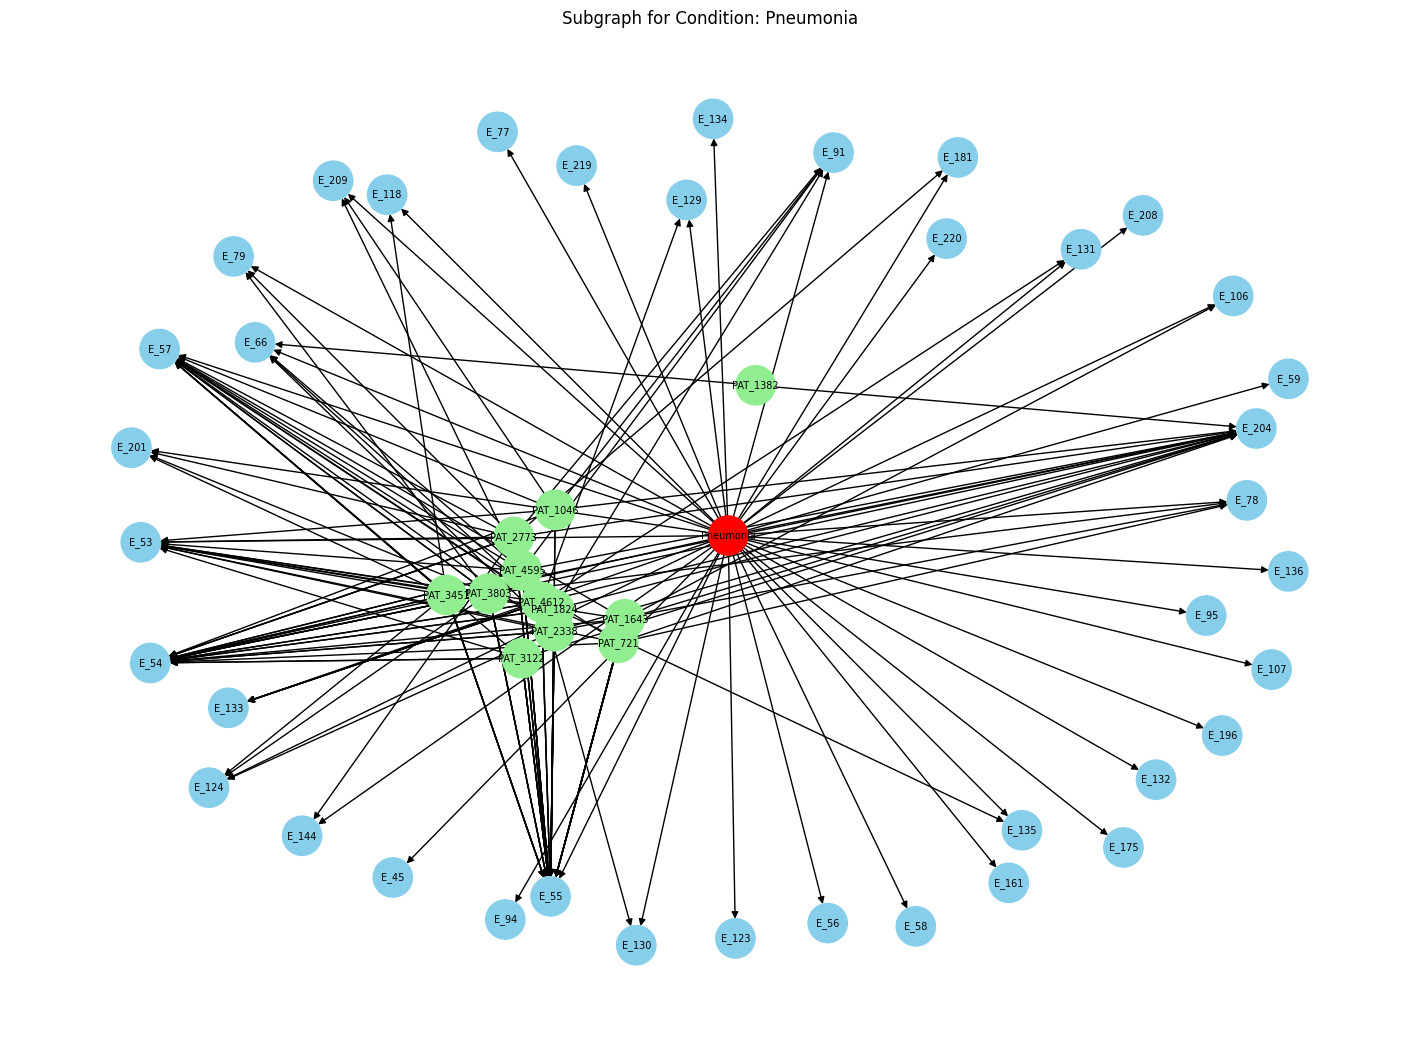

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

def visualize_condition(G, condition_name, num_patients=10):
    # Get subgraph nodes
    ev_nodes = [
        nbr for nbr, d in G[condition_name].items()
        if any(e["relation"] in ["HAS_SYMPTOM", "HAS_ANTECEDENT"]
               for e in d.values())
    ]

    pat_candidates = []
    for p in (n for n,t in G.nodes(data="type") if t == "patient"):
        if any(e in G[p] for e in ev_nodes):
            pat_candidates.append(p)
    
    sampled_patients = random.sample(pat_candidates, min(num_patients, len(pat_candidates)))

    nodes = {condition_name} | set(ev_nodes) | set(sampled_patients)
    subG = G.subgraph(nodes)

    # Plot
    pos = nx.spring_layout(subG, seed=42)
    plt.figure(figsize=(14, 10))
    colors = []

    for n in subG:
        if G.nodes[n]["type"] == "condition":
            colors.append("red")
        elif G.nodes[n]["type"] == "evidence":
            colors.append("skyblue")
        else:
            colors.append("lightgreen")

    nx.draw(subG, pos, node_color=colors, with_labels=True,
            font_size=7, node_size=800)
    plt.title(f"Subgraph for Condition: {condition_name}")
    plt.show()

# Example usage:
visualize_condition(G, "Pneumonia", num_patients=12)


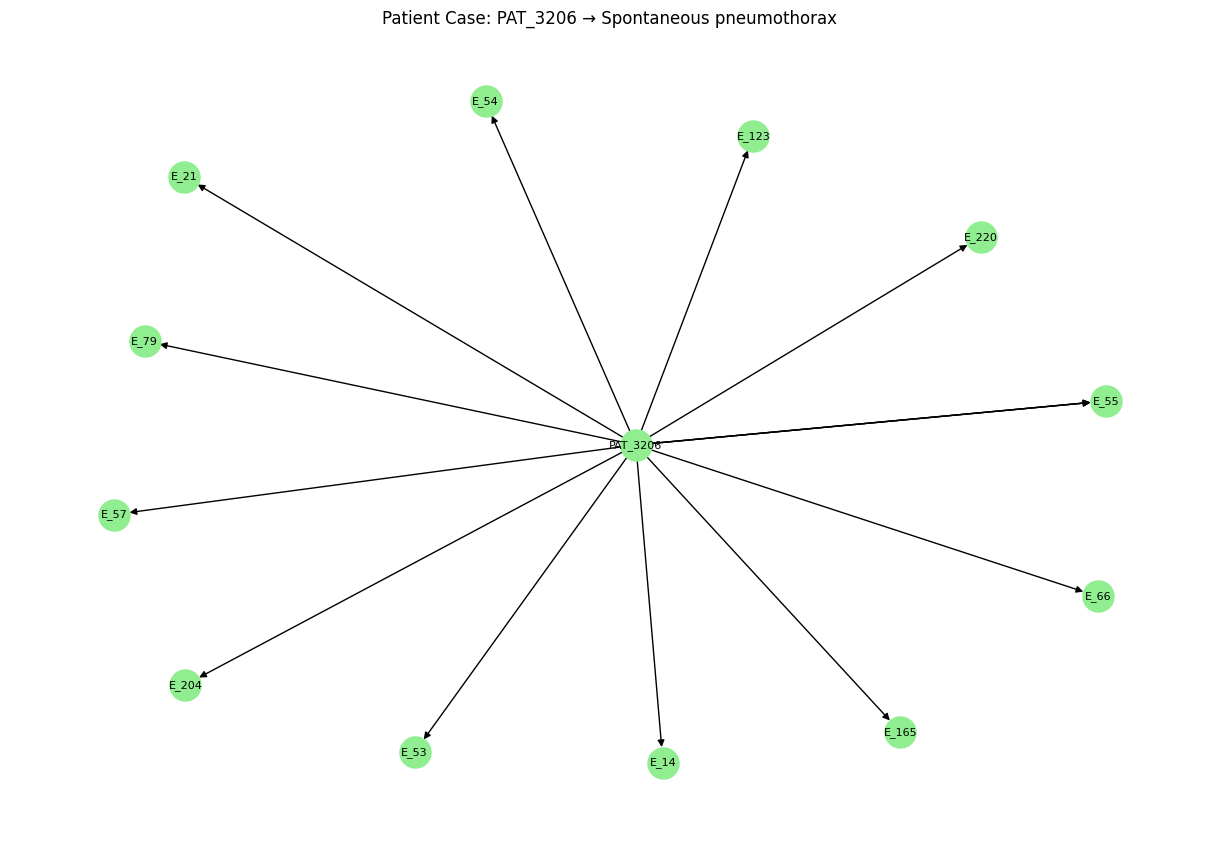

In [33]:
def visualize_patient_case(G, patient_id):
    ev_nodes = [
        nbr for nbr, d in G[patient_id].items()
        if any(e["relation"] == "HAS_EVIDENCE" for e in d.values())
    ]
    nodes = {patient_id} | set(ev_nodes)
    subG = G.subgraph(nodes)

    pos = nx.spring_layout(subG, seed=42)
    plt.figure(figsize=(12, 8))

    nx.draw(subG, pos,
            node_color="lightgreen",
            with_labels=True,
            font_size=8,
            node_size=500)
    plt.title(f"Patient Case: {patient_id} → {G.nodes[patient_id]['pathology']}")
    plt.show()

# Example usage:
visualize_patient_case(G, "PAT_3206")


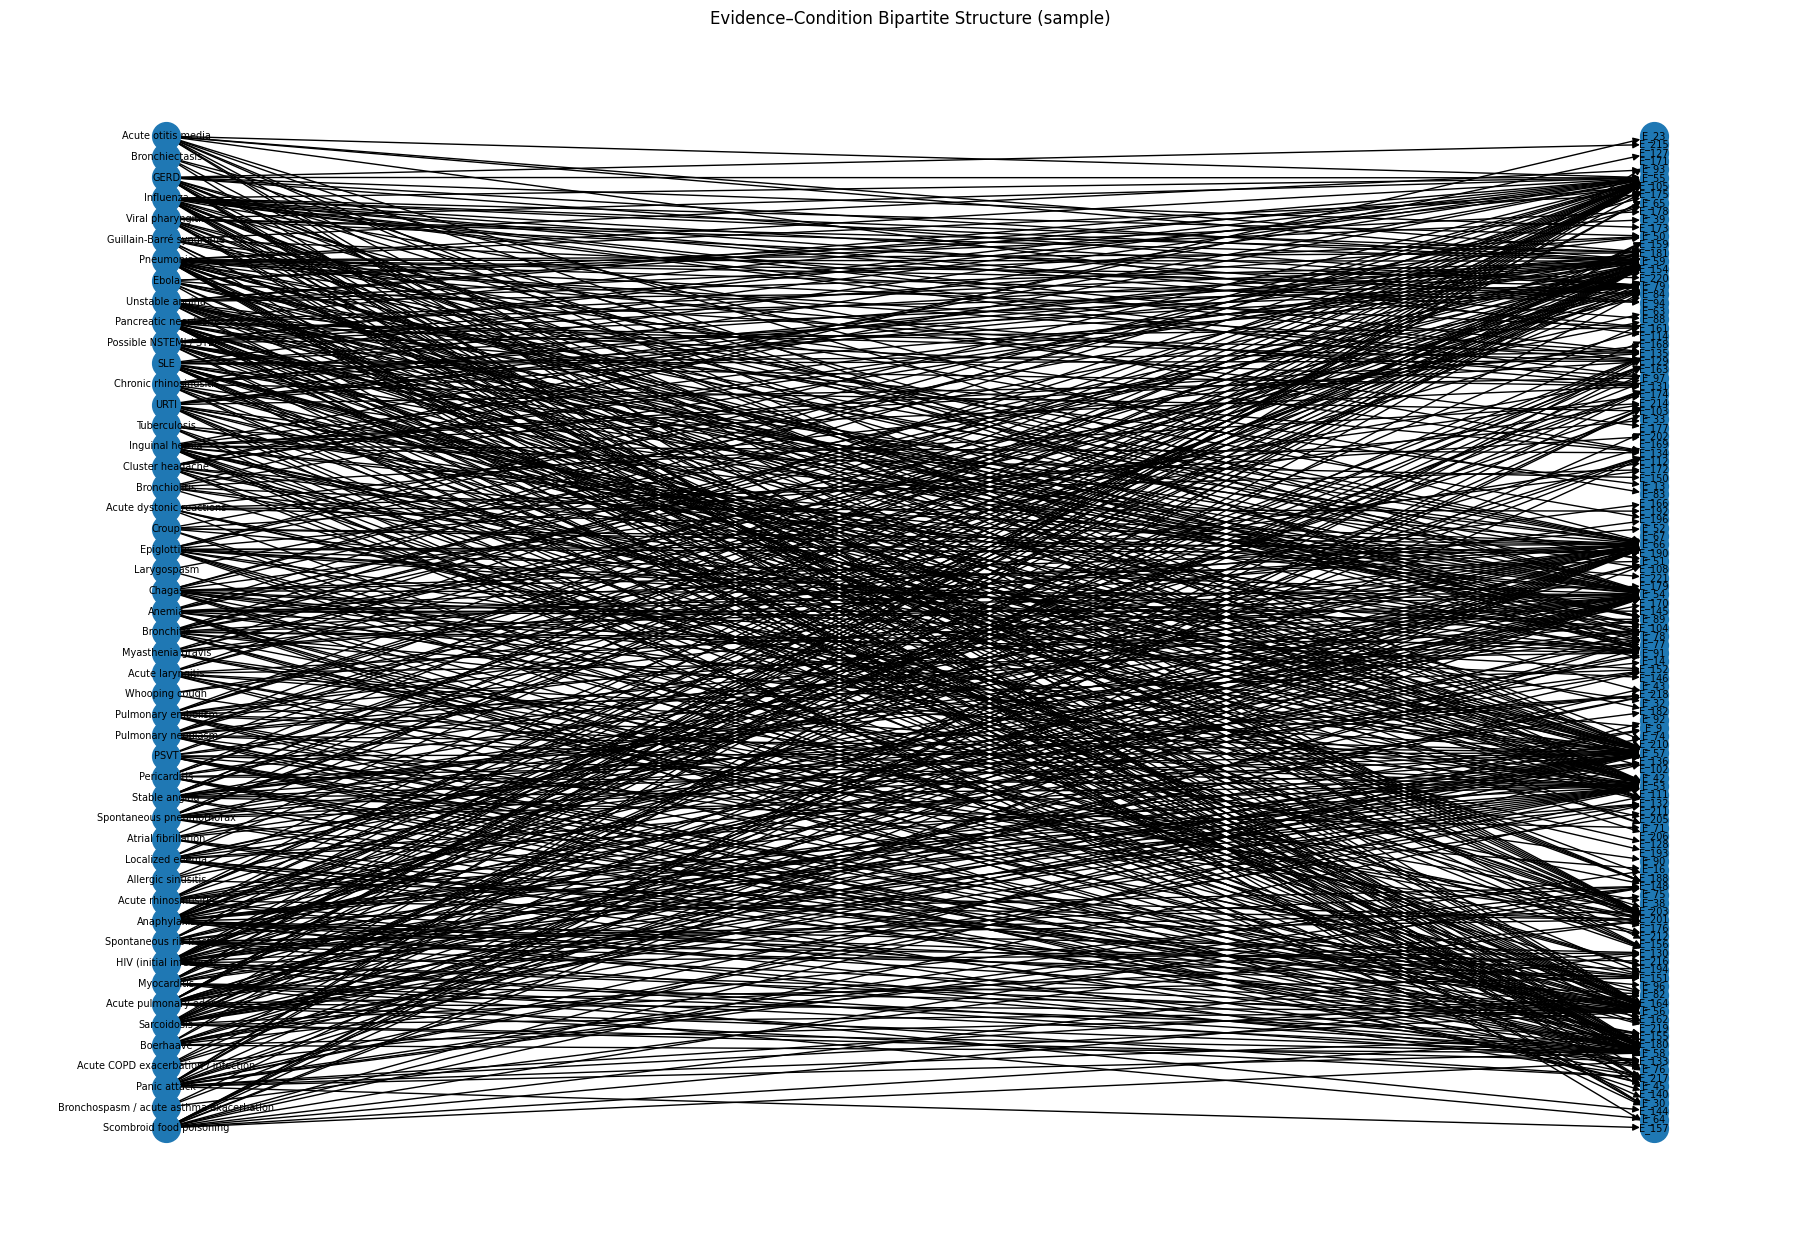

In [34]:
def visualize_evidence_condition(G, max_nodes=200):
    cond_nodes = [n for n,t in G.nodes(data="type") if t=="condition"]
    ev_nodes = [n for n,t in G.nodes(data="type") if t=="evidence"]

    # Subsample for sanity
    cond_nodes = cond_nodes[:min(max_nodes, len(cond_nodes))]
    ev_nodes = ev_nodes[:min(max_nodes, len(ev_nodes))]

    nodes = set(cond_nodes) | set(ev_nodes)
    subG = G.subgraph(nodes)

    pos = nx.bipartite_layout(subG, cond_nodes)
    plt.figure(figsize=(18, 12))

    nx.draw(subG, pos, with_labels=True,
            node_size=400, font_size=7)
    plt.title("Evidence–Condition Bipartite Structure (sample)")
    plt.show()

visualize_evidence_condition(G, max_nodes=120)


In [13]:
from collections import Counter
import networkx as nx

node_types = Counter(nx.get_node_attributes(G, "type").values())
edge_types = Counter([d["relation"] for *_, d in G.edges(data=True)])

print("Node types:", node_types)
print("Edge types:", edge_types)


Node types: Counter({'patient': 5000, 'evidence': 223, 'value': 144, 'condition': 49})
Edge types: Counter({'HAS_EVIDENCE': 83473, 'HAS_VALUE': 43006, 'HAS_SYMPTOM': 605, 'HAS_ANTECEDENT': 283})


In [7]:
print(df_patients.shape)
print(len(conditions))
print(len(evidences))


(1025602, 6)
49
223


In [16]:
from collections import defaultdict, Counter
import math

def build_condition_stats(G):
    cond_prior = Counter()              # P(d)
    cond_ev_count = defaultdict(Counter) # counts of evidence per condition
    cond_total = Counter()              # number of patients per condition

    for pid, data in G.nodes(data=True):
        if data.get("type") != "patient":
            continue

        truth = data.get("pathology")
        if not truth:
            continue

        cond_prior[truth] += 1
        cond_total[truth] += 1

        # all evidences observed for this patient
        evs = {
            nbr for nbr, edata in G[pid].items()
            if any(e.get("relation") == "HAS_EVIDENCE" for e in edata.values())
        }

        for ev in evs:
            cond_ev_count[truth][ev] += 1

    N = sum(cond_prior.values())
    cond_prior_prob = {c: cnt / N for c, cnt in cond_prior.items()}

    stats = {
        "prior": cond_prior_prob,
        "ev_count": cond_ev_count,
        "total": cond_total,
    }
    return stats


In [ ]:
def condition_evidences(G, cond):
    evs = set()
    for nbr, edata in G[cond].items():
        if any(e["relation"] in ["HAS_SYMPTOM", "HAS_ANTECEDENT"] 
               for e in edata.values()):
            evs.add(nbr)

    # NEW: include evidence from patient links
    for p in (n for n,t in G.nodes(data="type") if t=="patient"):
        if cond in G[p]:  # patient linked to condition?
            for nbr, edata in G[p].items():
                if any(e["relation"]=="HAS_EVIDENCE" for e in edata.values()):
                    evs.add(nbr)

    return evs


# def score_conditions(G, known_evs, candidates):
#     scores = {}
#     for cond in candidates:
#         ce = condition_evidences(G, cond)
#         if not ce: continue
#         inter = len(ce & known_evs)
#         if inter == 0: continue
#         scores[cond] = inter / len(ce)
#     return sorted(scores.items(), key=lambda x:x[1], reverse=True)

# def discriminative_evidence(G, candidates, known_evs, top_k=5):
#     freq = {}
#     for c in candidates:
#         for ev in condition_evidences(G, c):
#             if ev not in known_evs:
#                 freq[ev] = freq.get(ev, 0) + 1

#     N = len(candidates)
#     scores = {ev: f*(N-f) for ev,f in freq.items() if 0 < f < N}
#     ranked = sorted(scores.items(), key=lambda x:x[1], reverse=True)
#     return [ev for ev,_ in ranked[:top_k]]


In [17]:
stats = build_condition_stats(G)

In [23]:
def score_conditions_bayes_fixed(G, known_evs, stats,
                                 candidates=None,
                                 gamma=0.2,
                                 use_missing_penalty=False,
                                 alpha=1e-1,
                                 missing_penalty=0.1):
    prior = stats["prior"]
    ev_count = stats["ev_count"]
    total = stats["total"]

    if candidates is None:
        candidates = [n for n,t in G.nodes(data="type") if t=="condition"]

    scores = {}
    for c in candidates:
        if c not in prior:
            continue

        # softened prior
        logp = gamma * math.log(prior[c] + 1e-12)

        expected_evs = condition_evidences(G, c)
        if not expected_evs:
            continue

        # only evidences that both are known and expected
        for e in known_evs & expected_evs:
            num = ev_count[c][e]
            den = total[c]
            p_ed = (num + alpha) / (den + 2 * alpha)
            logp += math.log(p_ed + 1e-12)

        if use_missing_penalty:
            missing = expected_evs - known_evs
            frac_missing = len(missing) / max(len(expected_evs), 1)
            logp -= missing_penalty * frac_missing

        scores[c] = logp

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)


In [24]:
from collections import Counter

def discriminative_evidence_stats(G, candidates, known_evs, top_k=5,
                                  min_support=1):
    """
    candidates: list[(condition, score)] from score_conditions_bayes
    known_evs: set of evidences already known for this patient
    """
    cand_conds = [c for c, _ in candidates]
    N = len(cand_conds)
    if N <= 1:
        return []

    ev_support = Counter()

    for c in cand_conds:
        evs = {
            nbr for nbr, d in G[c].items()
            if any(e["relation"] in ["HAS_SYMPTOM", "HAS_ANTECEDENT"]
                   for e in d.values())
        }
        for e in evs:
            if e in known_evs:
                continue
            ev_support[e] += 1

    ev_scores = {}
    for e, f in ev_support.items():
        if f < min_support or f == 0 or f == N:
            # either too rare or present in all candidates → useless
            continue
        # entropy-like score: max when f ≈ N/2
        p = f / N
        score = - (p * math.log(p) + (1 - p) * math.log(1 - p))
        ev_scores[e] = score

    ranked = sorted(ev_scores.items(), key=lambda x: x[1], reverse=True)
    return [e for e, _ in ranked[:top_k]]


In [25]:
def candidate_conditions_with_overlap(G, known_evs):
    conds = []
    for c, t in G.nodes(data="type"):
        if t != "condition":
            continue
        evs = condition_evidences(G, c)
        if evs & known_evs:   # at least one overlap
            conds.append(c)
    return conds


In [41]:
df_test = pd.read_csv(".././Data/release_test_patients.csv")
df_test = df_test.sample(n=10, random_state=42).reset_index(drop=True)

In [53]:
turns = 4
pattern = re.compile(r'^(E_\d+)(?:_@_V_\d+)?$')

for idx, row in df_test.iterrows():
    pid = f"TEST_{idx}"
    truth = row["PATHOLOGY"]
    
    # get initial evidence
    init_raw = row["INITIAL_EVIDENCE"]
    m = pattern.match(init_raw)
    if not m:
        continue
    known = {m.group(1)}

    # parse full evidence list for ground-truth answers
    evs_full = set()
    for ev in eval(row["EVIDENCES"]):
        m = pattern.match(ev)
        if m:
            evs_full.add(m.group(1))

    print(f"\nTest Patient {pid} | Truth: {truth}")
    print(f" Initial evidence: {known}")

    # loop turns
    for turn in range(turns):
        # step 1 + 2: scoring
        cands = candidate_conditions_with_overlap(G, known)
        ranked = score_conditions_bayes_fixed(
            G, known, stats, candidates=cands,
            gamma=0.0, use_missing_penalty=False
        )
        top10 = [c for c,_ in ranked[:10]]
        print(f" Turn {turn}: Top10 => {top10}")
        print("   ✔ Truth in Top10" if truth in top10 else "   ❌ Missed")

        # step 3: pick next question
        if turn < turns - 1:
            next_ev_list = discriminative_evidence_stats(G, ranked[:20], known, top_k=1)
            if not next_ev_list:
                break
            qe = next_ev_list[0]
            print(f"   Asking: {qe}")
            
            # step 4: simulate patient answer
            has_ev = (qe in evs_full)
            print(f"   Answer: {'YES' if has_ev else 'NO'}")
            
            # update known and prune
            if has_ev:
                known.add(qe)
                cands = [c for c in cands if qe in condition_evidences(G, c)]
            else:
                cands = [c for c in cands if qe not in condition_evidences(G, c)]



Test Patient TEST_0 | Truth: Bronchospasm / acute asthma exacerbation
 Initial evidence: {'E_201'}
 Turn 0: Top10 => ['Tuberculosis', 'Bronchitis', 'Acute rhinosinusitis', 'Influenza', 'Chronic rhinosinusitis', 'Acute COPD exacerbation / infection', 'Pneumonia', 'Pulmonary neoplasm', 'Bronchospasm / acute asthma exacerbation', 'Bronchiectasis']
   ✔ Truth in Top10
   Asking: E_66
   Answer: YES
 Turn 1: Top10 => ['SLE', 'Acute rhinosinusitis', 'Influenza', 'Atrial fibrillation', 'Acute pulmonary edema', 'Chronic rhinosinusitis', 'Myocarditis', 'Panic attack', 'Pulmonary embolism', 'Spontaneous pneumothorax']
   ❌ Missed
   Asking: E_79
   Answer: NO
 Turn 2: Top10 => ['SLE', 'Acute rhinosinusitis', 'Influenza', 'Atrial fibrillation', 'Acute pulmonary edema', 'Chronic rhinosinusitis', 'Myocarditis', 'Panic attack', 'Pulmonary embolism', 'Spontaneous pneumothorax']
   ❌ Missed
   Asking: E_79
   Answer: NO
 Turn 3: Top10 => ['SLE', 'Acute rhinosinusitis', 'Influenza', 'Atrial fibrillati

In [44]:
ev_nodes = [n for n,t in G.nodes(data="type") if t=="evidence"]
print("Total evidence nodes in KG:", len(ev_nodes))

Total evidence nodes in KG: 223


In [46]:
evidence_node_with_max_edges = [max(
    ((n, G.degree(n)) for n in ev_nodes), key=lambda x: x[1])]
print("Evidence node with max edges:", evidence_node_with_max_edges)

Evidence node with max edges: [('E_55', 31672)]


In [ ]:
import json

FIELDS_TO_REMOVE = {"question_fr", "possible-values"}

def compact_json(input_path, output_path):
    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for _, question in data.items():
        # Remove unwanted top-level fields
        for field in FIELDS_TO_REMOVE:
            question.pop(field, None)

        # Clean value_meaning -> remove "fr"
        if "value_meaning" in question and isinstance(question["value_meaning"], dict):
            for _, meanings in question["value_meaning"].items():
                if isinstance(meanings, dict):
                    meanings.pop("fr", None)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(data, f, separators=(",", ":"), ensure_ascii=False)

if __name__ == "__main__":
    compact_json(".././Data/ddxplus/release_evidences.json", ".././Data/ddxplus/release_evidences.compact.json")


: 